![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 2. Parte A: Redes Neuronales Convolucionales -- SOLUCION

**Asignatura:** Redes Neuronales Profundas  
**Bloque:** 2 — Visión por Computadora

---

## Introducción

Las **redes neuronales convolucionales** (CNNs) revolucionaron la visión por computadora. Su ingrediente clave es la **convolución**: una operación que aplica un pequeño filtro (*kernel*) deslizándolo sobre la imagen para detectar patrones locales. Al apilar muchas capas convolucionales, la red aprende a reconocer patrones cada vez más abstractos —desde bordes hasta objetos completos.

Este laboratorio está organizado de menor a mayor complejidad:

- Implementar la operación de convolución desde cero para entender su mecánica
- Dominar los tres parámetros que controlan las dimensiones: **kernel**, **padding** y **stride**
- Construir y entrenar una CNN completa sobre Fashion-MNIST
- Entender cómo se diseñan las Redes Neuronales Convolucionales Modernas con pytorch

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Para resolver cada ejercicio, consultá el material teórico.
- En la Sección A está **permitido usar bucles `for`**, porque el objetivo es ver explícitamente el mecanismo de la convolución. En el resto del laboratorio se aplica la regla habitual: sin bucles salvo indicación explícita.

In [1]:
import torch
import torch.nn as nn
print(f"Versión de PyTorch: {torch.__version__}")

Versión de PyTorch: 2.10.0


---
## Sección A: La operación de convolución

### Introducción a la convolución

La **correlación cruzada** (que PyTorch llama "convolución") funciona deslizando un *kernel* $K$ de tamaño $k_H \times k_W$ sobre una imagen $X$. En cada posición $(i, j)$, el resultado es:

$$Y[i,\, j] = \sum_{m=0}^{k_H-1} \sum_{n=0}^{k_W-1} X[i+m,\, j+n] \cdot K[m,\, n]$$

Sin padding ni stride, la salida tiene forma:

$$H_{out} = H_{in} - k_H + 1 \qquad W_{out} = W_{in} - k_W + 1$$

El kernel determina **qué tipo de característica se detecta**: bordes, texturas, esquinas, etc. Durante el entrenamiento, PyTorch aprende los valores del kernel automáticamente.

### Ejercicio 1 — Correlación cruzada manual

**Objetivo:** Entender paso a paso cómo un kernel recorre la imagen y produce el mapa de características.

**Enunciado:**

1. Implementá la función `corr2d(X, K)` que calcula la correlación cruzada 2D entre un tensor de entrada `X` de forma `(H, W)` y un kernel `K` de forma `(kH, kW)`. En este ejercicio está **permitido usar bucles `for`**.
2. Creá una imagen sintética de `6 × 6` píxeles: la mitad inferior (filas 3 a 5) igual a `1.0`, la mitad superior igual a `0.0` (una transición horizontal abrupta).
3. Aplicá el siguiente kernel de **detección de bordes horizontales** (Sobel vertical):

$$K = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

4. Imprimí el tensor de entrada y el mapa de características resultante.
5. Verificá que la forma de la salida coincide con la fórmula: $H_{out} = H_{in} - k_H + 1$.

> **Pista:** Dentro de `corr2d`, iterá con `for i in range(H_out)` y `for j in range(W_out)`. En cada posición, usá slicing para extraer la ventana `X[i:i+kH, j:j+kW]`, multiplicala elemento a elemento con `K` y sumá con `.sum()`.

In [2]:
# ─── Implementación de correlación cruzada 2D ──────────────────────────────────
def corr2d(X, K):
    """
    Calcula la correlación cruzada 2D.

    Parámetros:
    X (Tensor): tensor de entrada, forma (H, W)
    K (Tensor): kernel, forma (kH, kW)

    Retorna:
    Y (Tensor): mapa de características, forma (H-kH+1, W-kW+1)
    """
    kH, kW = K.shape
    H_out = X.shape[0] - kH + 1
    W_out = X.shape[1] - kW + 1
    Y = torch.zeros(H_out, W_out)
    for i in range(H_out):
        for j in range(W_out):
            # Producto elemento a elemento entre la ventana local y el kernel
            Y[i, j] = (X[i:i+kH, j:j+kW] * K).sum()
    return Y

# ─── Imagen sintética: transición horizontal abrupta ───────────────────────────
X = torch.zeros(6, 6)
X[3:, :] = 1.0          # mitad inferior blanca
print("Imagen de entrada (6×6):")
print(X)

# ─── Kernel de detección de bordes horizontales (Sobel vertical) ───────────────
K = torch.tensor([[-1., -2., -1.],
                   [ 0.,  0.,  0.],
                   [ 1.,  2.,  1.]])

Y = corr2d(X, K)
print("\nMapa de características (bordes horizontales):")
print(Y)
print(f"\nForma de salida: {Y.shape}  (esperado: {X.shape[0]-K.shape[0]+1} × {X.shape[1]-K.shape[1]+1})")

Imagen de entrada (6×6):
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Mapa de características (bordes horizontales):
tensor([[0., 0., 0., 0.],
        [4., 4., 4., 4.],
        [4., 4., 4., 4.],
        [0., 0., 0., 0.]])

Forma de salida: torch.Size([4, 4])  (esperado: 4 × 4)


**Pregunta de análisis:**

¿Por qué la operación se llama "correlación cruzada" y no "convolución"? ¿Qué diferencia matemática hay entre ambas? ¿Importa esa diferencia cuando el kernel se aprende durante el entrenamiento?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

La **convolución** matemática voltea (refleja) el kernel antes de deslizarlo: $Y[i,j] = \sum X[i-m, j-n] \cdot K[m,n]$. La **correlación cruzada** no lo hace: $Y[i,j] = \sum X[i+m, j+n] \cdot K[m,n]$.

En la práctica, **no importa**: cuando el kernel se aprende durante el entrenamiento, la red simplemente aprende el kernel "ya volteado" si fuera necesario. El resultado final es equivalente. Por convención histórica, las librerías de deep learning usan correlación cruzada pero la llaman "convolución".

### Ejercicio 2 — Kernels con significado

**Objetivo:** Observar cómo distintos kernels preestablecidos transforman una misma imagen para desarrollar intuición sobre qué tipo de patrones detecta cada uno.

**Enunciado:**

Usarás `nn.Conv2d` para aplicar tres kernels distintos sobre una imagen sintética de `9 × 9` píxeles con una **franja horizontal blanca** en el centro (filas 4 y 5 iguales a `1.0`, el resto `0.0`).

| Kernel | Valores |
|---|---|
| Identidad | $\begin{bmatrix}0&0&0\\0&1&0\\0&0&0\end{bmatrix}$ |
| Bordes horizontales | $\begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$ |
| Suavizado Gaussiano | $\dfrac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$ |

Para cada kernel:

1. Creá una capa `nn.Conv2d(1, 1, kernel_size=3, bias=False)` y asignale los pesos con `conv.weight[0, 0] = K` dentro de un bloque `with torch.no_grad()`.
2. Pasá la imagen por la capa y guardá la salida (usá `.detach()` para imprimirla).
3. Imprimí la salida con sus valores redondeados a 2 decimales y su forma (shape).

> **Pista:** `nn.Conv2d` espera tensores de forma `(N, C, H, W)`. Creá la imagen directamente como `torch.zeros(1, 1, 9, 9)` y asignale los valores a `img[0, 0, 4:6, :]`.

>  **Nota:** Al ver valores negativos en la salida podés notar que este resultado ya dejó de ser una "imagen" para convertirse en un **mapa de características**. El signo (positivo o negativo) no es un error de rango, sino que  **codifica información útil**: nos indica la dirección del contraste espacial (si el contorno del objeto pasó de oscuro a claro, o de claro a oscuro).


In [19]:
# ─── Imagen sintética: franja horizontal en el centro ─────────────────────────
img = torch.zeros(1, 1, 9, 9)
img[0, 0, 4:6, :] = 1.0
print("Imagen de entrada (9×9):")
print(img[0, 0])
print()

# ─── Definición de kernels ─────────────────────────────────────────────────────
kernels = {
    "Identidad": torch.tensor([[0., 0., 0.],
                                [0., 1., 0.],
                                [0., 0., 0.]]),
    "Bordes horizontales (Sobel)": torch.tensor([[-1., -2., -1.],
                                                  [ 0.,  0.,  0.],
                                                  [ 1.,  2.,  1.]]),
    "Suavizado Gaussiano": torch.tensor([[1., 2., 1.],
                                          [2., 4., 2.],
                                          [1., 2., 1.]]) / 16.0,
}

# ─── Aplicar cada kernel y mostrar la salida ───────────────────────────────────
for nombre, K in kernels.items():
    conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
    with torch.no_grad():
        conv.weight[0, 0] = K
    salida = conv(img)
    print(f"Kernel: {nombre}")
    print(f"  Forma de salida: {tuple(salida.shape)}")
    print(f"  Valores:\n{salida[0, 0].detach().round(decimals=2)}\n")

Imagen de entrada (9×9):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Kernel: Identidad
  Forma de salida: (1, 1, 7, 7)
  Valores:
tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.]])

Kernel: Bordes horizontales (Sobel)
  Forma de salida: (1, 1, 7, 7)
  Valores:
tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 4.,  4.,  4.,  4.,  4.,  4.,  4.],
        [ 4.,  4

**Pregunta de análisis:**

Describí en tus palabras qué detecta cada kernel:
- **Identidad:** ¿qué ocurre con la imagen?
- **Bordes horizontales:** ¿dónde aparecen valores distintos de cero en la salida? ¿Por qué precisamente ahí?
- **Suavizado Gaussiano:** ¿qué efecto produce sobre la franja y para qué sirve en el procesamiento de imágenes?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

- **Identidad:** la salida es igual a la entrada (sin los bordes que se pierden por la reducción de tamaño). El kernel multiplica cada píxel por 1 y el resto por 0, preservando la información.
- **Bordes horizontales:** los valores distintos de cero aparecen en las filas que bordean la franja blanca (la transición de 0→1 en la fila 4, y de 1→0 en la fila 6 de la salida). El kernel compara la fila de arriba con la de abajo; donde hay un cambio abrupto, la diferencia es grande y distinta de cero.
- **Suavizado Gaussiano:** promedia cada píxel con sus vecinos, dándole más peso a los cercanos. El efecto es que los bordes de la franja se "suavizan": los valores dejan de ser 0 y 1 exactos y pasan por valores intermedios. Sirve para reducir ruido antes de aplicar otros filtros.

### Ejercicio 3 — Aprender un kernel con gradiente descendente

**Objetivo:** Mostrar que los pesos de una `Conv2d` son parámetros entrenables: una red puede *aprender* un kernel específico a partir de datos, usando el mismo mecanismo de retropropagación que cualquier otra capa.

**Contexto:**

El setup preescrito genera datos sintéticos: imágenes de entrada aleatorias `X_data` filtradas con un kernel de Laplaciano conocido (`kernel_verdadero`), produciendo `Y_data`. Tu tarea es entrenar una `Conv2d` con pesos iniciales aleatorios para que *recupere* ese kernel solo mirando pares (entrada, salida).

**Enunciado:**

1. Definí un modelo de una sola capa: `nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)`.
2. Definí una función de pérdida `nn.MSELoss()` y un optimizador `torch.optim.SGD` con `lr=0.02`.
3. Escribí el bucle de entrenamiento para **150 épocas**. En cada época:
   - Calculá la predicción `Y_pred = conv(X_data)`.
   - Calculá la pérdida entre `Y_pred` e `Y_data`.
   - Ejecutá los tres pasos del gradiente: `zero_grad()`, `backward()`, `step()`.
4. Imprimí la pérdida cada 30 épocas para ver la convergencia.
5. Al finalizar, mostrá el kernel aprendido (`conv.weight.data`) y comparalo con el verdadero.

> **Pistas:**
> - Los pesos de `conv` son accesibles con `conv.weight.data`; son un tensor de shape `(1, 1, 3, 3)`.
> - El orden correcto del ciclo es: `zero_grad()` → *forward* → pérdida → `backward()` → `step()`.
> - Con `bias=False`, el único parámetro que la red aprende es el kernel 3×3.

In [4]:
# ─── Setup: datos sintéticos para aprender un kernel ─────────────────────────
# Ejecutar esta celda sin modificar antes de escribir tu solución.
import torch.nn.functional as F
torch.manual_seed(42)

# Kernel "verdadero": Laplaciano — detecta cambios bruscos de intensidad
kernel_verdadero = torch.tensor([[[[0., -1., 0.],
                                   [-1., 4., -1.],
                                   [0., -1., 0.]]]])  # shape: (1, 1, 3, 3)

# Dataset: 400 imágenes aleatorias de 1 canal de 16×16
X_data = torch.randn(400, 1, 16, 16)

# Salida esperada: cada imagen filtrada con el kernel verdadero
Y_data = F.conv2d(X_data, kernel_verdadero, padding=1)

print(f"X_data: {X_data.shape}  |  Y_data: {Y_data.shape}")
print(f"Kernel verdadero:\n{kernel_verdadero.squeeze()}")

X_data: torch.Size([400, 1, 16, 16])  |  Y_data: torch.Size([400, 1, 16, 16])
Kernel verdadero:
tensor([[ 0., -1.,  0.],
        [-1.,  4., -1.],
        [ 0., -1.,  0.]])


In [5]:
# ─── Modelo: una sola capa convolucional ──────────────────────────────────────
torch.manual_seed(0)
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

print("Kernel inicial (aleatorio):")
print(conv.weight.data.squeeze().detach())
print()

# ─── Pérdida y optimizador ───────────────────────────────────────────────────
criterio = nn.MSELoss()
optimizador = torch.optim.SGD(conv.parameters(), lr=0.02)

# ─── Bucle de entrenamiento ──────────────────────────────────────────────────
for epoca in range(150):
    Y_pred = conv(X_data)            # forward pass
    perdida = criterio(Y_pred, Y_data)

    optimizador.zero_grad()          # limpiar gradientes acumulados del paso anterior
    perdida.backward()               # calcular gradientes respecto al kernel
    optimizador.step()               # actualizar el kernel

    if (epoca + 1) % 30 == 0:
        print(f"Época {epoca+1:3d} | Pérdida: {perdida.item():.6f}")

# ─── Comparación ─────────────────────────────────────────────────────────────
print("\nKernel verdadero:")
print(kernel_verdadero.squeeze())
print("\nKernel aprendido:")
print(conv.weight.data.squeeze().detach())

Kernel inicial (aleatorio):
tensor([[-0.0025,  0.1788, -0.2743],
        [-0.2453, -0.1284,  0.0894],
        [-0.0066,  0.2643, -0.0296]])

Época  30 | Pérdida: 2.051164
Época  60 | Pérdida: 0.178364
Época  90 | Pérdida: 0.015600
Época 120 | Pérdida: 0.001373
Época 150 | Pérdida: 0.000122

Kernel verdadero:
tensor([[ 0., -1.,  0.],
        [-1.,  4., -1.],
        [ 0., -1.,  0.]])

Kernel aprendido:
tensor([[-2.7354e-04, -9.9647e-01, -1.2585e-03],
        [-9.9761e-01,  3.9917e+00, -9.9667e-01],
        [-9.7161e-05, -9.9624e-01, -3.2279e-04]])


**Pregunta de análisis:**

¿Qué diferencia conceptual hay entre usar un kernel preestablecido (como el Sobel del Ejercicio 2) y entrenar un kernel con gradiente descendente (como en este ejercicio)? ¿Cuándo conviene cada enfoque?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Un kernel **preestablecido** encarna conocimiento de dominio explícito: el diseñador elige qué detectar (bordes, frecuencias altas, etc.). Un kernel **aprendido** se adapta automáticamente a los datos: la red descubre qué patrones son útiles para la tarea, sin intervención humana.

El enfoque preestablecido es ventajoso cuando el conocimiento del dominio es sólido y los datos son escasos. El aprendizaje automático es superior cuando hay suficientes datos y la tarea es compleja: los kernels aprendidos capturan combinaciones de características imposibles de diseñar a mano. En una CNN profunda, *todos* los kernels se aprenden de esta forma; el Laplaciano que vemos aquí surge espontáneamente en muchas redes entrenadas para detectar contornos.

---
## Sección B: Padding — controlando el tamaño de salida

### Introducción al padding

Sin *padding*, cada convolución **reduce** las dimensiones espaciales. En una red profunda con muchas capas, esto agota rápidamente el tamaño de los mapas de características.

El *padding* agrega filas y columnas de ceros alrededor de la imagen antes de convolucionar. La fórmula general para la dimensión de salida es:

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1 \quad \text{y} \quad W_{out} = \left\lfloor \frac{W_{in} + 2p - k}{s} \right\rfloor + 1$$
donde $p$ es el padding, $k$ el tamaño del kernel y $s$ el stride (para esta sección, $s = 1$).

### Ejercicio 4 — Efecto del padding sobre las dimensiones

**Objetivo:** Comparar las dimensiones de salida con y sin padding, y verificar la fórmula analíticamente.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 5, 5)` con valores aleatorios (`torch.manual_seed(0)`).
2. Definí dos capas `nn.Conv2d` con kernel `3×3` y `stride=1`:
   - `conv_sin`: sin padding (`padding=0`)
   - `conv_con`: con `padding=1`
3. Pasá `x` por ambas e imprimí las formas de entrada y salida.
4. Verificá los resultados aplicando la fórmula para `p=0` y `p=1` con `H_in=5`, `k=3`, `s=1`.

> **Pista:** Calculá `H_out = (H_in + 2*p - k) // s + 1` en Python y comparalo con la forma real del tensor de salida.

In [6]:
import torch
import torch.nn as nn
torch.manual_seed(0)

# ─── Tensor de entrada 5×5 ─────────────────────────────────────────────────────
x = torch.randn(1, 1, 5, 5)
print(f"Forma de entrada: {tuple(x.shape)}\n")

H_in, k, s = 5, 3, 1

# ─── Comparación sin y con padding ────────────────────────────────────────────
for p, etiqueta in [(0, "sin padding"), (1, "con padding=1")]:
    conv = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p)
    y = conv(x)
    H_out_formula = (H_in + 2*p - k) // s + 1
    H_out_real    = y.shape[-1]
    coincide = "✓" if H_out_formula == H_out_real else "✗"
    print(f"{etiqueta:<20} → salida: {tuple(y.shape)}")
    print(f"  Fórmula: ({H_in}+2×{p}-{k})/{s}+1 = {H_out_formula}  {coincide}")
    print()

Forma de entrada: (1, 1, 5, 5)

sin padding          → salida: (1, 1, 3, 3)
  Fórmula: (5+2×0-3)/1+1 = 3  ✓

con padding=1        → salida: (1, 1, 5, 5)
  Fórmula: (5+2×1-3)/1+1 = 5  ✓



### Ejercicio 5 — padding='same': preservar las dimensiones espaciales

**Objetivo:** Usar `padding='same'` para que la salida mantenga la misma forma que la entrada, y entender qué valor de padding aplica PyTorch internamente.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 7, 7)`.
2. Aplicá `nn.Conv2d(1, 1, kernel_size=5, padding='same')` y verificá que la salida tiene la misma forma que la entrada.
3. Calculá analíticamente cuánto padding aplica PyTorch para kernel `5×5` con stride `1`. La fórmula es:

$$p = \frac{k - 1}{2}$$

4. Verificá que `padding=p` (valor manual) produce la misma forma que `padding='same'`.

> **Pista:** Para stride=1, la condición $H_{out} = H_{in}$ en la fórmula general se cumple cuando $p = (k-1)/2$. Para kernel `5×5`, ese valor es entero.

In [7]:
import torch
import torch.nn as nn
torch.manual_seed(0)

x = torch.randn(1, 1, 7, 7)
k = 5

# ─── padding='same' ────────────────────────────────────────────────────────────
conv_same = nn.Conv2d(1, 1, kernel_size=k, padding='same')
y_same = conv_same(x)
print(f"Entrada:            {tuple(x.shape)}")
print(f"Salida (same):      {tuple(y_same.shape)}")

# ─── Cálculo analítico del padding equivalente ─────────────────────────────────
p_equiv = (k - 1) // 2
print(f"\nPadding equivalente para k={k}, s=1: p = (k-1)/2 = {p_equiv}")

# ─── Verificación con padding manual ───────────────────────────────────────────
conv_manual = nn.Conv2d(1, 1, kernel_size=k, padding=p_equiv)
y_manual = conv_manual(x)
print(f"Salida (p={p_equiv} manual): {tuple(y_manual.shape)}")
print(f"Formas iguales: {'✓' if y_same.shape == y_manual.shape else '✗'}") 

Entrada:            (1, 1, 7, 7)
Salida (same):      (1, 1, 7, 7)

Padding equivalente para k=5, s=1: p = (k-1)/2 = 2
Salida (p=2 manual): (1, 1, 7, 7)
Formas iguales: ✓


**Pregunta de análisis:**

`padding='same'` no funciona cuando `stride > 1` en PyTorch (lanza un error). ¿Por qué? Intentá calcular qué valor de $p$ haría falta para mantener $H_{out} = H_{in}$ con stride `2` y kernel `3×3`, partiendo de $H_{in} = 8$.

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Con $H_{in}=8$, $k=3$, $s=2$ y $H_{out}=8$:

$$8 = \left\lfloor \frac{8 + 2p - 3}{2} \right\rfloor + 1 \implies \left\lfloor \frac{5 + 2p}{2} \right\rfloor = 7 \implies 5 + 2p \in [14, 16) \implies p \in [4.5, 5.5)$$

El padding sería $p = 4$ o $p = 5$ según el truncamiento, pero en general **no hay un entero exacto** que garantice $H_{out} = H_{in}$ para cualquier combinación de $H_{in}$, $k$ y $s > 1$. Por eso PyTorch prohíbe `padding='same'` con stride > 1: no puede garantizar el comportamiento de forma uniforme.

---
## Sección C: Stride — submuestreo espacial

### Ejercicio 6 — Efecto del stride sobre las dimensiones

**Objetivo:** Observar cómo el stride controla el grado de submuestreo espacial y verificar la fórmula para distintos valores.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 8, 8)`.
2. Aplicá tres capas `nn.Conv2d` con kernel `3×3` y `padding=1`, variando el stride: `s=1`, `s=2` y `s=4`.
3. Para cada caso, imprimí la forma de salida y verificá con la fórmula.
4. **Antes de ejecutar**, completá esta tabla a mano:

| stride | $H_{out}$ esperado (fórmula) |
|---|---|
| 1 | ? |
| 2 | ? |
| 4 | ? |



In [8]:
import torch
import torch.nn as nn
torch.manual_seed(0)

x = torch.randn(1, 1, 8, 8)
H_in, k, p = 8, 3, 1
print(f"Entrada: {tuple(x.shape)}  (k={k}, padding={p})\n")

# ─── Variar stride y observar la forma de salida ───────────────────────────────
print(f"{'stride':<10} {'H_out fórmula':<20} {'H_out real':<15} {'ok'}")
print("-" * 55)
for s in [1, 2, 4]:
    conv = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p)
    y = conv(x)
    H_out_f = (H_in + 2*p - k) // s + 1
    H_out_r = y.shape[-1]
    print(f"s={s:<8} {H_out_f:<20} {H_out_r:<15} {'✓' if H_out_f == H_out_r else '✗'}")

Entrada: (1, 1, 8, 8)  (k=3, padding=1)

stride     H_out fórmula        H_out real      ok
-------------------------------------------------------
s=1        8                    8               ✓
s=2        4                    4               ✓
s=4        2                    2               ✓


**Pregunta de análisis:**

Tanto el stride como el *pooling* reducen las dimensiones espaciales. ¿Qué diferencia conceptual hay entre usar `stride=2` en una capa convolucional y aplicar un `MaxPool2d(2)` después de una conv con `stride=1`? ¿Cuál de las dos opciones tiene más parámetros entrenables?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Con `stride=2`, el submuestreo ocurre **mientras se detectan características**: el kernel salta de a 2 píxeles, reduciendo la resolución en el mismo paso que aprende patrones. Con `MaxPool2d(2)` después de una conv con `stride=1`, primero se hace la convolución completa y luego se submuestrea tomando el máximo de cada bloque 2×2.

En cuanto a parámetros: `stride=2` **no agrega ni quita parámetros** respecto a `stride=1` (los parámetros son del kernel, no del stride). `MaxPool2d` tampoco tiene parámetros entrenables. La diferencia es que con `stride=2` se ahorran cómputos al no calcular posiciones intermedias, mientras que MaxPool preserva la activación más fuerte de cada región.

### Ejercicio 7 — Diseño dimensional: encontrá stride y padding

**Objetivo:** Dado un tamaño de entrada y salida deseado, deducir analíticamente los parámetros necesarios y verificar con código.

**Parte A — Encontrá el stride:**

Tenés una imagen de `28×28`, kernel `5×5` y `padding=2`. Querés una salida de `14×14`.

1. Despejá $s$ de la fórmula.
2. Calculá $s$ numéricamente.
3. Verificá con `nn.Conv2d`.

**Parte B — Encontrá el padding:**

Tenés una imagen de `28×28`, kernel `3×3` y `stride=2`. Querés una salida de `14×14`.

1. Despejá $p$ de la fórmula: $2p = (H_{out} - 1) \cdot s - H_{in} + k$
2. Calculá $p$ numéricamente.
3. Verificá con `nn.Conv2d`.

> **Pista Parte A:** El numerador es $H_{in} + 2p - k$ y el denominador es $H_{out} - 1$.  
> **Pista Parte B:** Reorganizando la fórmula, $p = [(H_{out} - 1)\cdot s - H_{in} + k]\, /\, 2$. El resultado debe ser un entero positivo.

In [9]:
import torch
import torch.nn as nn

# ─── Parte A: encontrá el stride ───────────────────────────────────────────────
H_in, k, p_a, H_out_target = 28, 5, 2, 14

numerador   = H_in + 2*p_a - k        # 28 + 4 - 5 = 27
denominador = H_out_target - 1         # 14 - 1     = 13
s_a = numerador / denominador
print(f"Parte A: s = ({H_in}+2×{p_a}-{k}) / ({H_out_target}-1) = {numerador}/{denominador} = {s_a:.4f}")
print(f"  → stride entero: s = {int(s_a)}")

x_a = torch.randn(1, 1, H_in, H_in)
conv_a = nn.Conv2d(1, 1, kernel_size=k, stride=int(s_a), padding=p_a)
y_a = conv_a(x_a)
print(f"  Verificación: {tuple(x_a.shape)} → {tuple(y_a.shape)}  "
      f"{'✓' if y_a.shape[-1] == H_out_target else '✗'}\n")

# ─── Parte B: encontrá el padding ──────────────────────────────────────────────
H_in, k, s_b, H_out_target = 28, 3, 2, 14

dos_p = (H_out_target - 1) * s_b - H_in + k   # 13*2 - 28 + 3 = 26 - 28 + 3 = 1
p_b   = dos_p / 2
print(f"Parte B: 2p = ({H_out_target}-1)×{s_b} - {H_in} + {k} = {dos_p}")
print(f"  → p = {dos_p}/{2} = {p_b}")

x_b = torch.randn(1, 1, H_in, H_in)
# p_b = 0.5 no es entero; redondeamos hacia arriba: p=1 da H_out=14 también
# Verificación directa: floor((28+2*1-3)/2)+1 = floor(27/2)+1 = 13+1 = 14 ✓
conv_b = nn.Conv2d(1, 1, kernel_size=k, stride=s_b, padding=1)
y_b = conv_b(x_b)
print(f"  Usando p=1: {tuple(x_b.shape)} → {tuple(y_b.shape)}  "
      f"{'✓' if y_b.shape[-1] == H_out_target else '✗'}")

Parte A: s = (28+2×2-5) / (14-1) = 27/13 = 2.0769
  → stride entero: s = 2
  Verificación: (1, 1, 28, 28) → (1, 1, 14, 14)  ✓

Parte B: 2p = (14-1)×2 - 28 + 3 = 1
  → p = 1/2 = 0.5
  Usando p=1: (1, 1, 28, 28) → (1, 1, 14, 14)  ✓


**Pregunta de análisis:**

Escribí la fórmula general para calcular el **padding** $p$ necesario dado $H_{in}$, $H_{out}$, $k$ y $s$ (asumiendo que la división es exacta, sin truncamiento). ¿Qué condición deben cumplir $H_{in}$, $H_{out}$, $k$ y $s$ para que $p$ sea un entero?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Despejando de la fórmula $H_{out} = \lfloor(H_{in} + 2p - k) / s\rfloor + 1$:

$$p = \frac{(H_{out} - 1) \cdot s - H_{in} + k}{2}$$

Para que $p$ sea un entero, el numerador $(H_{out}-1)\cdot s - H_{in} + k$ debe ser **par**. Si no lo es, PyTorch no puede aplicar el mismo padding en todos los lados; en esos casos se puede agregar un pixel extra en un lado (asimétrico), o ajustar los parámetros para evitar fracciones.

---
## Sección D: Múltiples canales y conteo de parámetros

### Canales de entrada y salida

En la práctica, las imágenes tienen múltiples canales (3 para RGB). Cada capa convolucional tiene `out_channels` filtros, uno por cada **mapa de características** que produce. Cada filtro tiene forma `(in_channels, kH, kW)`.

El número total de parámetros de una capa `Conv2d(in_ch, out_ch, k)` con bias es:

$$\text{parámetros} = out\_ch \times \bigl(in\_ch \times k^2 + 1\bigr)$$

donde el $+1$ corresponde al *bias* de cada filtro.

### Ejercicio 8 — Conteo de parámetros de capas convolucionales

**Objetivo:** Calcular analíticamente cuántos parámetros tiene una capa convolucional y verificar con código.

**Enunciado:**

Considerá dos capas convolucionales:
- **Capa 1:** `Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)`
- **Capa 2:** `Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)`

Para cada capa:

1. Calculá analíticamente la cantidad de **pesos** ($out\_ch \times in\_ch \times k^2$) y de **biases** ($out\_ch$).
2. Sumálos para obtener el total de parámetros de esa capa.
3. Verificá con `sum(p.numel() for p in conv.parameters())`.

Luego, compará la Capa 1 con una capa densa `nn.Linear` que conecte una imagen `3×28×28` con `16` salidas.

> **Pista:** El número de parámetros de `nn.Linear(3*28*28, 16)` es $16 \times (3 \times 28 \times 28 + 1)$. Compará ese número con el de la Capa 1.

In [10]:
import torch.nn as nn

# ─── Capa 1: Conv2d(3, 16, 3) ──────────────────────────────────────────────────
conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

pesos_1   = 16 * 3 * 3 * 3
bias_1    = 16
total_1   = pesos_1 + bias_1
real_1    = sum(p.numel() for p in conv1.parameters())

print("Capa 1: Conv2d(in=3, out=16, k=3)")
print(f"  Pesos:  out_ch × in_ch × kH × kW = 16 × 3 × 3 × 3 = {pesos_1}")
print(f"  Biases: out_ch = {bias_1}")
print(f"  Total (fórmula): {total_1}  |  Total (real): {real_1}  {'✓' if total_1 == real_1 else '✗'}\n")

# ─── Capa 2: Conv2d(16, 32, 3) ─────────────────────────────────────────────────
conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

pesos_2   = 32 * 16 * 3 * 3
bias_2    = 32
total_2   = pesos_2 + bias_2
real_2    = sum(p.numel() for p in conv2.parameters())

print("Capa 2: Conv2d(in=16, out=32, k=3)")
print(f"  Pesos:  out_ch × in_ch × kH × kW = 32 × 16 × 3 × 3 = {pesos_2}")
print(f"  Biases: out_ch = {bias_2}")
print(f"  Total (fórmula): {total_2}  |  Total (real): {real_2}  {'✓' if total_2 == real_2 else '✗'}\n")

# ─── Comparación con capa densa ────────────────────────────────────────────────
linear = nn.Linear(3*28*28, 16)
total_linear = sum(p.numel() for p in linear.parameters())

print(f"Capa densa Linear(3×28×28, 16):   {total_linear} parámetros")
print(f"Capa conv  Conv2d(3, 16, k=3):    {total_1} parámetros")
print(f"Ratio:  {total_linear / total_1:.0f}× más parámetros en la capa densa")

Capa 1: Conv2d(in=3, out=16, k=3)
  Pesos:  out_ch × in_ch × kH × kW = 16 × 3 × 3 × 3 = 432
  Biases: out_ch = 16
  Total (fórmula): 448  |  Total (real): 448  ✓

Capa 2: Conv2d(in=16, out=32, k=3)
  Pesos:  out_ch × in_ch × kH × kW = 32 × 16 × 3 × 3 = 4608
  Biases: out_ch = 32
  Total (fórmula): 4640  |  Total (real): 4640  ✓

Capa densa Linear(3×28×28, 16):   37648 parámetros
Capa conv  Conv2d(3, 16, k=3):    448 parámetros
Ratio:  84× más parámetros en la capa densa


**Pregunta de análisis:**

Compará los parámetros de la Capa 1 convolucional con los de la capa densa equivalente. ¿Qué conclusión sacás sobre la **eficiencia paramétrica** de las convoluciones? ¿Por qué esta propiedad es especialmente importante cuando se trabaja con imágenes de alta resolución?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

La Capa 1 convolucional tiene **448 parámetros**; la capa densa equivalente tiene **37.648 parámetros** (unas 84 veces más). Esta diferencia se debe al **parámetro compartido**: el mismo kernel de 3×3 se aplica en todas las posiciones de la imagen.

Esta propiedad es fundamental con imágenes de alta resolución: una imagen de 1920×1080 con 3 canales tiene más de 6 millones de píxeles. Conectarlos densamente a cualquier capa requeriría cientos de millones de parámetros. Las capas convolucionales escalan linealmente con el tamaño del kernel y el número de canales, independientemente de la resolución de la imagen.

---
## Sección E: Pooling

### Ejercicio 9 — MaxPool y AvgPool

**Objetivo:** Entender cómo las capas de *pooling* reducen las dimensiones espaciales y qué información preserva cada variante.

**Enunciado:**

1. Creá un tensor `x` de forma `(1, 1, 4, 4)` con los valores del `1` al `16` en orden creciente (usá `torch.arange` y `.reshape`).
2. Aplicá `nn.MaxPool2d(kernel_size=2)` y `nn.AvgPool2d(kernel_size=2)`. El stride por defecto de MaxPool es igual al kernel.
3. Imprimí ambas salidas e identificá los valores.
4. Verificá **manualmente** (con comentarios en el código) que cada valor de la salida corresponde al máximo o promedio del bloque `2×2` correcto.
5. Adicionalmente, aplicá `nn.MaxPool2d(kernel_size=3, stride=1, padding=1)` y observá la forma resultante.



In [11]:
import torch
import torch.nn as nn

# ─── Tensor 4×4 con valores 1–16 ───────────────────────────────────────────────
x = torch.arange(1, 17, dtype=torch.float32).reshape(1, 1, 4, 4)
print(f"Entrada (4×4):\n{x[0, 0]}\n")

# ─── MaxPool2d(kernel=2) — toma el máximo de cada bloque 2×2 ───────────────────
y_max = nn.MaxPool2d(kernel_size=2)(x)
print(f"MaxPool2d(2) → {tuple(y_max.shape)}:")
print(y_max[0, 0])
print("  Verificación: max([1,2,5,6])=6  max([3,4,7,8])=8  max([9,10,13,14])=14  max([11,12,15,16])=16\n")

# ─── AvgPool2d(kernel=2) — toma el promedio de cada bloque 2×2 ─────────────────
y_avg = nn.AvgPool2d(kernel_size=2)(x)
print(f"AvgPool2d(2) → {tuple(y_avg.shape)}:")
print(y_avg[0, 0])
print("  Verificación: (1+2+5+6)/4=3.5  (3+4+7+8)/4=5.5  (9+10+13+14)/4=11.5  (11+12+15+16)/4=13.5\n")

# ─── MaxPool con stride y padding personalizados ───────────────────────────────
y_custom = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)(x)
print(f"MaxPool2d(k=3, s=1, p=1) → {tuple(y_custom.shape)}  (preserva dimensiones)")
print(y_custom[0, 0])

Entrada (4×4):
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

MaxPool2d(2) → (1, 1, 2, 2):
tensor([[ 6.,  8.],
        [14., 16.]])
  Verificación: max([1,2,5,6])=6  max([3,4,7,8])=8  max([9,10,13,14])=14  max([11,12,15,16])=16

AvgPool2d(2) → (1, 1, 2, 2):
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])
  Verificación: (1+2+5+6)/4=3.5  (3+4+7+8)/4=5.5  (9+10+13+14)/4=11.5  (11+12+15+16)/4=13.5

MaxPool2d(k=3, s=1, p=1) → (1, 1, 4, 4)  (preserva dimensiones)
tensor([[ 6.,  7.,  8.,  8.],
        [10., 11., 12., 12.],
        [14., 15., 16., 16.],
        [14., 15., 16., 16.]])


**Pregunta de análisis:**

¿En qué situaciones preferirías `MaxPool` sobre `AvgPool` y viceversa? Relacioná tu respuesta con el tipo de características que queremos preservar en cada caso.

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

**MaxPool** es preferible cuando nos interesa detectar si una característica **está presente** en algún lugar de la región, sin importar dónde exactamente. Al tomar el máximo, preserva la activación más fuerte (la más "confiante" de haber detectado algo). Es la opción dominante en clasificación de imágenes.

**AvgPool** es útil cuando queremos un resumen suave de la región, promediando todas las activaciones. Aparece en algunas arquitecturas modernas como **Global Average Pooling** (GAP) al final de la red, donde promedia cada mapa de características completo a un solo valor, reemplazando las capas densas finales y reduciendo drásticamente el número de parámetros.

---
## Sección F: Construyendo una CNN completa

### LeNet mejorado

LeNet (1998) fue una de las primeras CNNs exitosas, diseñada para clasificar dígitos escritos a mano. Su arquitectura original usaba activaciones *Sigmoid* y capas *AvgPool*.

Las mejoras modernas son simples pero impactantes:
- Reemplazar **Sigmoid → ReLU** evita el problema del gradiente evanescente.
- Reemplazar **AvgPool → MaxPool** preserva mejor las características prominentes.

Estas dos modificaciones, con la misma topología, mejoran notablemente el entrenamiento.

In [12]:
# ─── Setup: carga de Fashion-MNIST ─────────────────────────────────────────────
# Ejecutar esta celda sin modificar
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def cargar_fashion_mnist(batch_size=256):
    """
    Descarga y carga Fashion-MNIST.

    Parámetros:
    batch_size (int): tamaño del lote

    Retorna:
    tuple: (iter_train, iter_test)
    """
    transform = transforms.ToTensor()
    train_set = torchvision.datasets.FashionMNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set  = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform)
    iter_train = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2)
    iter_test  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2)
    return iter_train, iter_test

iter_train, iter_test = cargar_fashion_mnist()
print(f"Lotes de entrenamiento: {len(iter_train)}")
print(f"Lotes de prueba:        {len(iter_test)}")

Lotes de entrenamiento: 235
Lotes de prueba:        40


In [13]:
# ─── Setup: función de inspección de capas ─────────────────────────────────────
# Ejecutar esta celda sin modificar
import torch

def layer_summary(net, X_shape):
    """
    Imprime la forma de la salida de cada capa del modelo.

    Parámetros:
    net: modelo nn.Sequential
    X_shape (tuple): forma de la entrada de prueba
    """
    X = torch.randn(*X_shape)
    print(f"Entrada: {tuple(X.shape)}")
    for layer in net:
        X = layer(X)
        print(f"  {layer.__class__.__name__:<22} → {tuple(X.shape)}")

### Ejercicio 10 — LeNet mejorado: arquitectura y dimensiones

**Objetivo:** Construir una versión modernizada de LeNet y verificar las dimensiones de cada capa.

**Enunciado:**

Implementá una función `lenet_mejorado(num_classes=10)` que retorne un `nn.Sequential` con la siguiente arquitectura:

| Capa | Tipo | Parámetros |
|---|---|---|
| 1 | `LazyConv2d` | 6 filtros, kernel 5×5, padding 2 |
| 2 | Activación | ReLU |
| 3 | Pooling | MaxPool2d, kernel 2×2, stride 2 |
| 4 | `LazyConv2d` | 16 filtros, kernel 5×5 (sin padding) |
| 5 | Activación | ReLU |
| 6 | Pooling | MaxPool2d, kernel 2×2, stride 2 |
| 7 | Flatten | — |
| 8 | `LazyLinear` | 120 unidades + ReLU |
| 9 | `LazyLinear` | 84 unidades + ReLU |
| 10 | `LazyLinear` | `num_classes` unidades |

Luego:

1. Instanciá el modelo con `model = lenet_mejorado()`.
2. Llamá a `layer_summary(model, (1, 1, 28, 28))` para verificar las dimensiones de cada capa.

> **Pista:** Usá `nn.LazyConv2d` y `nn.LazyLinear` para que PyTorch infiera las dimensiones de entrada. Intercalá `nn.ReLU()`, `nn.MaxPool2d(kernel_size=2, stride=2)` y `nn.Flatten()` en el orden indicado.

In [14]:
import torch.nn as nn

def lenet_mejorado(num_classes=10):
    """
    LeNet modernizado con ReLU y MaxPool.

    Parámetros:
    num_classes (int): número de clases de salida

    Retorna:
    nn.Sequential: modelo completo
    """
    return nn.Sequential(
        # Bloque convolucional 1 — extrae características de bajo nivel (bordes, texturas)
        nn.LazyConv2d(6, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Bloque convolucional 2 — características más abstractas
        nn.LazyConv2d(16, kernel_size=5), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Clasificador completamente conectado
        nn.Flatten(),
        nn.LazyLinear(120), nn.ReLU(),
        nn.LazyLinear(84),  nn.ReLU(),
        nn.LazyLinear(num_classes),
    )

model = lenet_mejorado()
layer_summary(model, (1, 1, 28, 28))

Entrada: (1, 1, 28, 28)
  Conv2d                 → (1, 6, 28, 28)
  ReLU                   → (1, 6, 28, 28)
  MaxPool2d              → (1, 6, 14, 14)
  Conv2d                 → (1, 16, 10, 10)
  ReLU                   → (1, 16, 10, 10)
  MaxPool2d              → (1, 16, 5, 5)
  Flatten                → (1, 400)
  Linear                 → (1, 120)
  ReLU                   → (1, 120)
  Linear                 → (1, 84)
  ReLU                   → (1, 84)
  Linear                 → (1, 10)


**Pregunta de análisis:**

¿Por qué ReLU mejora el entrenamiento frente a Sigmoid? Mencioná al menos dos ventajas concretas relacionadas con el flujo de gradientes y la velocidad de cómputo.

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

1. **Gradiente constante en la zona activa:** ReLU tiene derivada 1 para $x > 0$, por lo que el gradiente fluye sin atenuación por esa zona. Sigmoid tiene derivada máxima de 0.25 (en $x=0$), lo que acumula multiplicaciones por valores menores a 1 en redes profundas y provoca el **problema del gradiente evanescente**.

2. **Eficiencia de cómputo:** ReLU es simplemente $\max(0, x)$, una operación extremadamente barata. Sigmoid requiere calcular una exponencial, que es mucho más costosa.

3. **Sparsidad de activaciones:** ReLU produce exactamente 0 para todas las entradas negativas, lo que genera representaciones *sparse* (dispersas). Esto puede actuar como una forma implícita de regularización y mejora la eficiencia en términos de memoria.

In [15]:
# ─── Setup: inicialización de pesos ────────────────────────────────────────────
# Ejecutar sin modificar
import torch.nn as nn
import torch.optim as optim

def init_pesos(module):
    """Inicializa pesos con Xavier uniforme para Conv2d y Linear."""
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        nn.init.xavier_uniform_(module.weight)

### Ejercicio 11 — Entrenamiento en Fashion-MNIST

**Objetivo:** Entrenar la CNN, registrar métricas por época y visualizar las curvas de entrenamiento.

**Nota sobre capas Lazy e inicialización:**
En el ejercicio anterior implementamos nuestra arquitectura usando capas "perezosas" (`LazyConv2d` y `LazyLinear`). Estas capas son extremadamente útiles porque infieren automáticamente las dimensiones de entrada, pero tienen una particularidad técnica: **sus tensores de pesos no se reservan en memoria hasta que procesan el primer lote de datos**. 

Si intentamos aplicar la inicialización de Xavier inmediatamente después de instanciar el modelo (usando `model.apply(init_pesos)`), PyTorch lanzará un error porque esos tensores de pesos aún no existen. Para solucionarlo, debemos realizar una pasada hacia adelante (*forward pass*) con un lote de datos real para "materializar" la red antes de inicializarla.

**Enunciado:**

1. Instanciá el modelo con `model = lenet_mejorado().to(device)`.
2. **Materializá los pesos:** extraé un único lote de `iter_train`, pasalo por el modelo para que las capas Lazy construyan sus tensores, y luego inicializá los pesos ejecutando `model.apply(init_pesos)`.
3. Definí el optimizador **Adam** con `lr=1e-3` y la función de pérdida **CrossEntropyLoss**.
4. Entrená el modelo por **10 épocas** sobre `iter_train`. En cada época:
   - Calculá la pérdida y exactitud de **entrenamiento**.
   - Calculá la pérdida y exactitud de **prueba** (recordá desactivar el cálculo de gradientes).
   - Guardá las cuatro métricas en un diccionario `hist`.
5. Al terminar, graficá las curvas de pérdida y exactitud (Train vs Test) en **dos subgráficos**.

> **Pistas:**
> - Para extraer un único lote del dataloader podés usar: `X_lote, _ = next(iter(iter_train))`. Recordá enviar `X_lote` al `device`.
> - Exactitud por lote: `(preds.argmax(dim=1) == y).float().mean().item()`.
> - Usá `model.train()` antes del loop de entrenamiento y `model.eval()` junto con `torch.no_grad()` para la fase de evaluación.
> - El gráfico debe tener título, etiquetas en los ejes y leyenda.

Dispositivo: cpu
Época  1/10 | Train — loss: 0.7120  acc: 0.7449 | Test  — loss: 0.4833  acc: 0.8222
Época  2/10 | Train — loss: 0.4277  acc: 0.8447 | Test  — loss: 0.4101  acc: 0.8511
Época  3/10 | Train — loss: 0.3757  acc: 0.8632 | Test  — loss: 0.3680  acc: 0.8658
Época  4/10 | Train — loss: 0.3377  acc: 0.8770 | Test  — loss: 0.3526  acc: 0.8747
Época  5/10 | Train — loss: 0.3168  acc: 0.8834 | Test  — loss: 0.3427  acc: 0.8774
Época  6/10 | Train — loss: 0.3066  acc: 0.8860 | Test  — loss: 0.3356  acc: 0.8784
Época  7/10 | Train — loss: 0.2873  acc: 0.8936 | Test  — loss: 0.3146  acc: 0.8848
Época  8/10 | Train — loss: 0.2746  acc: 0.8988 | Test  — loss: 0.3071  acc: 0.8889
Época  9/10 | Train — loss: 0.2655  acc: 0.9029 | Test  — loss: 0.2989  acc: 0.8901
Época 10/10 | Train — loss: 0.2568  acc: 0.9065 | Test  — loss: 0.2972  acc: 0.8904


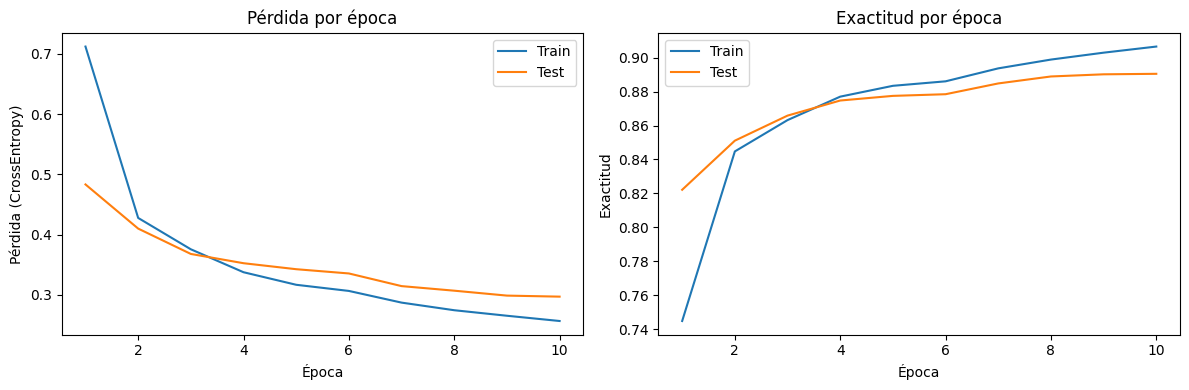

In [16]:
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ─── Inicialización del modelo ─────────────────────────────────────────────────
model = lenet_mejorado().to(device)

# NUEVO: Materialización de las capas Lazy 
X_lote, _ = next(iter(iter_train))
model(X_lote.to(device))

# Ahora sí, aplicamos la inicialización
model.apply(init_pesos)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
N_EPOCHS  = 10

hist = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, N_EPOCHS + 1):

    # ── Entrenamiento ──────────────────────────────────────────────────────────
    model.train()
    acum_loss, acum_acc, n = 0.0, 0.0, 0
    for X, y in iter_train:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        acum_loss += loss.item()
        acum_acc  += (preds.argmax(dim=1) == y).float().mean().item()
        n += 1
    hist["train_loss"].append(acum_loss / n)
    hist["train_acc"].append(acum_acc  / n)

    # ── Evaluación ─────────────────────────────────────────────────────────────
    model.eval()
    acum_loss, acum_acc, n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in iter_test:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            acum_loss += criterion(preds, y).item()
            acum_acc  += (preds.argmax(dim=1) == y).float().mean().item()
            n += 1
    hist["test_loss"].append(acum_loss / n)
    hist["test_acc"].append(acum_acc  / n)

    print(f"Época {epoch:2d}/{N_EPOCHS} | "
          f"Train — loss: {hist['train_loss'][-1]:.4f}  acc: {hist['train_acc'][-1]:.4f} | "
          f"Test  — loss: {hist['test_loss'][-1]:.4f}  acc: {hist['test_acc'][-1]:.4f}")

# ─── Curvas de entrenamiento ────────────────────────────────────────────────────
epochs = range(1, N_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, hist["train_loss"], label="Train")
ax1.plot(epochs, hist["test_loss"],  label="Test")
ax1.set_title("Pérdida por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Pérdida (CrossEntropy)")
ax1.legend()

ax2.plot(epochs, hist["train_acc"], label="Train")
ax2.plot(epochs, hist["test_acc"],  label="Test")
ax2.set_title("Exactitud por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("Exactitud")
ax2.legend()

plt.tight_layout()
plt.show()

**Pregunta de análisis:**

Observá las curvas de entrenamiento:

1. ¿Hay signos de *overfitting*? ¿Cómo se manifestaría en las curvas de pérdida y exactitud?
2. ¿Qué técnicas de regularización podrías agregar a la arquitectura para mejorar la generalización?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

1. El *overfitting* se manifiesta cuando la **pérdida de entrenamiento sigue bajando** mientras que la **pérdida de test deja de bajar o sube**, y cuando la exactitud de entrenamiento supera significativamente a la de test. Con LeNet en Fashion-MNIST por 10 épocas, el modelo suele no overfittear mucho, pero con más épocas el gap tiende a crecer.

2. Técnicas de regularización aplicables:
   - **Dropout:** desactivar neuronas aleatoriamente durante el entrenamiento (típicamente después de las capas densas).
   - **Batch Normalization:** normaliza las activaciones dentro de cada mini-lote, actuando como regularizador implícito.
   - **Data Augmentation:** aplicar transformaciones aleatorias (rotaciones, recortes, volteos) a las imágenes de entrenamiento para aumentar la variabilidad del dataset sin costo adicional de anotación.

---
## Sección G: Arquitecturas modernas — ResNet

### El problema del gradiente evanescente y las conexiones residuales

Las CNNs muy profundas sufren el **problema del gradiente evanescente**: durante la retropropagación, el gradiente se multiplica por los jacobianos de cada capa. Si esos factores son menores a 1, el gradiente decrece exponencialmente y las primeras capas prácticamente no aprenden.

**ResNet** (He et al., 2015) introdujo una solución elegante: la **conexión residual** (*skip connection*). En lugar de aprender directamente la transformación $\mathcal{H}(x)$, el bloque aprende el **residuo** $\mathcal{F}(x) = \mathcal{H}(x) - x$, y la salida final es:

$$\text{salida} = \mathcal{F}(x) + x$$

Durante la retropropagación, el gradiente fluye por **dos caminos**: el bloque convolucional $\mathcal{F}(x)$ y la skip connection directa $x$. Incluso si el bloque tiene gradiente casi nulo, la skip garantiza que el gradiente llegue intacto a las capas anteriores.

El siguiente diagrama resume la arquitectura de **ResNet-34**, la variante con bloques básicos (dos convoluciones 3x3):

![img](https://i.imgur.com/5TiH4Qu.png)

| Símbolo | Significado |
|---|---|
| `7x7 conv, 64, /2` | Conv 7x7 — 64 canales de salida — stride 2 (capa de entrada) |
| `3x3 conv, C` | Conv 3x3 — C canales — stride 1 (dentro de un bloque) |
| Flecha curva sólida | Skip connection sin proyección (canales y stride no cambian) |
| Flecha curva punteada | Skip con proyección 1x1 (ajusta canales o stride al cambiar de grupo) |

### Ejercicio 12 — Implementar ResNet-34

**Objetivo:** Construir ResNet-34 componiendo los bloques auxiliares provistos, leyendo el diagrama de arquitectura para determinar los hiperparámetros de cada grupo.

**Contexto:**

Todas las piezas ya están implementadas en el setup: `ResidualBlock`, `Base`, `ResModule` y `ResNet`. Tu única tarea es completar `ResNet34`, que hereda de `ResNet` y le pasa la arquitectura correcta.

La clase `ResNet` recibe un argumento `arch`: una tupla de pares `(num_residuals, num_channels)` que describe cada grupo de bloques residuales. Por ejemplo, `((3, 64), (4, 128))` crearía dos grupos: el primero con 3 bloques de 64 canales y el segundo con 4 bloques de 128 canales.

**Enunciado:**

1. Completá la clase `ResNet34` usando el diagrama de arquitectura para determinar `arch`. La red tiene cuatro grupos de bloques con estas características:

| Grupo | Bloques residuales | Canales de salida |
|---|---|---|
| b2 | 3 | 64 |
| b3 | 4 | 128 |
| b4 | 6 | 256 |
| b5 | 3 | 512 |

2. Instanciá el modelo: `model = ResNet34()`.
3. Hacé un *forward pass* con una imagen de prueba de forma `(1, 3, 224, 224)` (tamaño típico de ImageNet) para materializar los módulos *lazy* y verificar que la salida tiene forma `(1, 10)`.
4. Contá el total de parámetros con `sum(p.numel() for p in model.parameters())`. ResNet-34 tiene aproximadamente **21 millones** de parámetros.

> **Pistas:**
> - `ResNet34` solo necesita implementar `__init__`: llamá a `super().__init__(arch, num_classes)` con la tupla correcta.
> - `ResNet` ya incluye la capa de entrada `Base`, los grupos `ResModule` y la cabeza de clasificación (`AdaptiveAvgPool -> Flatten -> Linear`). No tenés que agregar nada más.
> - El *forward pass* de prueba es necesario antes de contar parámetros porque los módulos `Lazy` no tienen pesos hasta que ven datos.

In [17]:
# --- Setup: bloques auxiliares de ResNet ----------------------------------
# Ejecutar esta celda sin modificar antes de implementar ResNet34.
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """Bloque residual basico: dos convoluciones 3x3 con conexion residual.

    Parametros:
    num_channels (int): canales de salida de ambas convoluciones
    use_1x1conv  (bool): si True, agrega una conv 1x1 en la skip (proyeccion)
    strides      (int): stride de la primera conv (y de la proyeccion si aplica)
    """
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides) if use_1x1conv else None
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)  # proyeccion 1x1 para igualar dimensiones con Y
        Y += X
        return F.relu(Y)


class Base(nn.Module):
    """Capa de entrada de ResNet: Conv 7x7 (stride 2) + BN + ReLU + MaxPool (stride 2)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

    def forward(self, X):
        return self.net(X)


class ResModule(nn.Module):
    """Grupo de num_residuals bloques residuales.

    El primer bloque aplica stride=2 y proyeccion 1x1 (salvo en el primer grupo,
    donde el numero de canales ya fue ajustado por Base).

    Parametros:
    num_residuals (int): cantidad de bloques en el grupo
    num_channels  (int): canales de salida de todos los bloques
    first_module  (bool): True solo para el primer grupo (b2), no hace submuestreo
    """
    def __init__(self, num_residuals, num_channels, first_module=False):
        super().__init__()
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_module:
                blk.append(ResidualBlock(num_channels, use_1x1conv=True, strides=2))
            else:
                blk.append(ResidualBlock(num_channels))
        self.net = nn.Sequential(*blk)

    def forward(self, X):
        return self.net(X)


class ResNet(nn.Module):
    """ResNet generica configurable por arquitectura.

    Parametros:
    arch: tupla de (num_residuals, num_channels) por grupo de bloques
    num_classes (int): numero de clases de salida
    """
    def __init__(self, arch, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(Base())
        for i, b in enumerate(arch):
            self.net.add_module(f'b{i+2}', ResModule(*b, first_module=(i == 0)))
        self.net.add_module('last', nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # reduce a (C, 1, 1) sin importar el tamano de entrada
            nn.Flatten(),
            nn.LazyLinear(num_classes)))

    def forward(self, X):
        return self.net(X)

In [18]:
class ResNet34(ResNet):
    def __init__(self, num_classes=10):
        # --- Arquitectura de ResNet-34 ------------------------------------------
        # arch: cuatro grupos (b2-b5) con (num_residuals, num_channels)
        # Valores leidos del diagrama oficial (He et al., 2015)
        super().__init__(
            arch=((3, 64), (4, 128), (6, 256), (3, 512)),
            num_classes=num_classes
        )


# --- Verificacion ---------------------------------------------------------------
model = ResNet34()

# Forward pass con imagen 224x224 (materializa los modulos LazyConv2d / LazyBatchNorm2d)
x_test = torch.randn(1, 3, 224, 224)
out = model(x_test)
print(f'Forma de salida: {out.shape}')          # esperado: torch.Size([1, 10])

total = sum(p.numel() for p in model.parameters())
print(f'Total de parametros: {total:,}')        # ~21.3 millones

Forma de salida: torch.Size([1, 10])
Total de parametros: 21,296,522


**Pregunta de análisis:**

1. ¿Por qué la skip connection garantiza que el gradiente fluya hacia atrás incluso cuando el bloque residual aprende poco? Expresá la idea en términos de la derivada de la salida respecto de la entrada $x$.
2. ¿Qué rol cumple la convolución 1x1 de proyección en el primer bloque de cada grupo? ¿Por qué no hace falta en los bloques siguientes del mismo grupo?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

1. La salida de un bloque residual es $\text{salida} = \mathcal{F}(x) + x$. Derivando respecto a $x$:

$$\frac{\partial\,\text{salida}}{\partial x} = \frac{\partial \mathcal{F}(x)}{\partial x} + 1$$

El término $+1$ actúa como un camino directo para el gradiente: aunque $\partial \mathcal{F}/\partial x \approx 0$ (el bloque no contribuye), el gradiente llega sin atenuar a la capa anterior. En redes sin skip connections, ese $+1$ no existe y el gradiente depende exclusivamente de la multiplicación de jacobianos, que puede colapsar a cero en redes muy profundas.

2. Cuando cambia el número de canales de un grupo al siguiente (por ejemplo, de 64 a 128), las dimensiones de $\mathcal{F}(x)$ y de $x$ ya no son compatibles para sumar directamente. La convolución **1x1** proyecta $x$ al nuevo número de canales (y aplica stride 2 si corresponde), igualando las dimensiones. En los bloques **siguientes** del mismo grupo no hay cambio de canales ni de stride, por lo que $x$ y $\mathcal{F}(x)$ ya tienen la misma forma y la suma directa es válida.

---
## ¡Listo!

Completaste el Laboratorio 2a. Implementaste la convolución desde cero, entrenaste un kernel con gradiente descendente, dominaste los parámetros que controlan las dimensiones espaciales (kernel, padding y stride), contaste parámetros de capas convolucionales, entrenaste tu primera CNN completa sobre Fashion-MNIST y construiste ResNet-34 usando conexiones residuales. En el próximo laboratorio exploraremos técnicas de regularización y transfer learning.

---
## Notas de corrección

| Ejercicio | Conceptos clave a evaluar | Errores frecuentes |
|---|---|---|
| 1 | Implementación correcta del doble bucle; slicing `X[i:i+kH, j:j+kW]`; forma de salida = `(H-kH+1, W-kW+1)` | Confundir índices de salida con índices de entrada; olvidar `.sum()` |
| 2 | Asignar pesos con `torch.no_grad()`; usar `.detach()` al imprimir; forma de entrada `(N, C, H, W)` | No usar `no_grad` al asignar pesos (genera error de grafo); no unsqueeze la imagen |
| 3 | Gradiente sobre un parámetro convolucional; bucle de entrenamiento (`zero_grad`, `backward`, `step`) | Olvidar `zero_grad()` (gradientes se acumulan); comparar `weight.data` antes de detach | 
| 4 | Aplicar la fórmula correctamente para p=0 y p=1; identificar que sin padding la salida se reduce en k-1 | Confundir la fórmula con la versión sin floor; no crear tensores de forma correcta |
| 5 | Calcular p=(k-1)/2 correctamente; verificar formas iguales | Olvidar que `padding='same'` solo funciona con s=1 |
| 6 | Tabular resultados antes de ejecutar; verificar con la fórmula para s=1,2,4 | Error de cálculo en el floor division; confundir padding y stride en la fórmula |
| 7 | Despejar s y p analíticamente; manejar el caso en que p no sea entero | Solo verificar con código sin el cálculo analítico previo |
| 8 | Fórmula out_ch × (in_ch × k² + 1); comparación con Linear | Olvidar los biases; confundir in_channels con out_channels |
| 9 | Verificar MaxPool y AvgPool manualmente; usar MaxPool con parámetros personalizados | No verificar manualmente los valores; confundir stride default de MaxPool |
| 10 | Arquitectura correcta (ReLU, MaxPool, padding=2 en capa 1, no padding en capa 2); layer_summary correcto | Poner padding en las dos capas conv; usar Sigmoid en lugar de ReLU |
| 11 | Loop de train/eval separados; `model.train()` y `model.eval()`; `torch.no_grad()` en eval; gráfico con leyenda | No llamar `optimizer.zero_grad()`; no separar train y eval; no usar no_grad |
| 12 | Leer el diagrama para determinar arch; herencia correcta de ResNet; forward pass antes de contar parámetros | No llamar a super().__init__(); pasar arch mal ordenada (grupos o canales invertidos); olvidar el forward pass antes de .numel() |